In [1]:
import os, sys
import pandas as pd
import scanpy as sc
import anndata as ad

from scipy.sparse import issparse

In [2]:
os.chdir('/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/input-data')

#### Proceed with the day 2 data, + lapatinib

In [3]:
d2_dz = sc.read_h5ad("clustered_egfDuod_D2_DZ.h5ad")

In [4]:
d2_dz.obs["leiden"].dtype

CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
                  '12', '13', '14', '15', '16', '17', '18', '19', '20', '21',
                  '22', '23'],
, ordered=False, categories_dtype=object)

/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


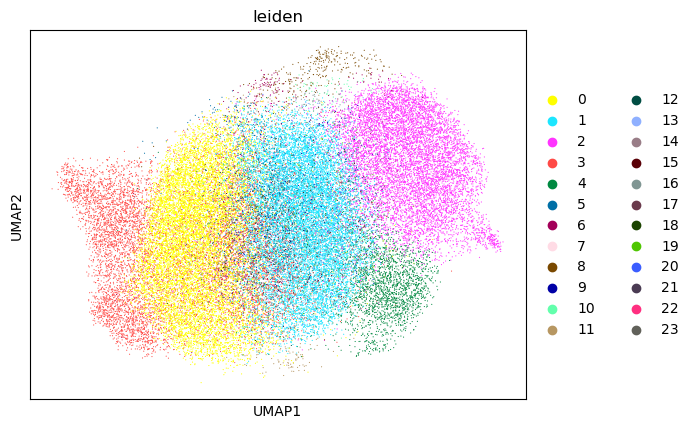

In [5]:
sc.pl.umap(d2_dz, color="leiden", palette=sc.pl.palettes.default_102,)

/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


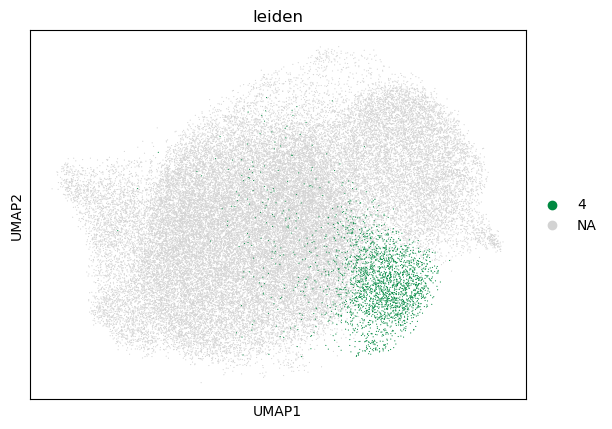

In [6]:
sc.pl.umap(d2_dz, color="leiden", palette=sc.pl.palettes.default_102, groups=["4"])

In [7]:
### Create a map of the new labels 

# For D2 Dz
d2_dz_map = {
    "0": "ISCs",
    "1": "ISCs",
    "2": "Proliferating progenitor cells",
    "3": "Enterocytes",
    "4": "Secretory PCs"
}



In [8]:
## Initialise a new slot in the scanpy object .obs

d2_dz.obs["manual_label"] = "Unlabeled"

In [9]:
for cl, lab in d2_dz_map.items():
    sel = d2_dz.obs["leiden"] == cl
    d2_dz.obs.loc[sel, "manual_label"] = lab

In [10]:
d2_dz.obs["manual_label"].head(20)

AAACCAAAGATACTCG-1                         Unlabeled
AAACCAAAGCCAACTA-1    Proliferating progenitor cells
AAACCAAAGGCACACT-1    Proliferating progenitor cells
AAACCAAAGGTGCTCG-1                     Secretory PCs
AAACCAAAGTCAACTG-1                         Unlabeled
AAACCAAAGTCATGTG-1                              ISCs
AAACCATTCAAGTGAA-1    Proliferating progenitor cells
AAACCATTCACAGCCG-1                              ISCs
AAACCATTCAGCGAAG-1                              ISCs
AAACCATTCCAACTGA-1                              ISCs
AAACCATTCCATAGTG-1                              ISCs
AAACCATTCCCGCGTT-1                       Enterocytes
AAACCATTCCGCGAAT-1                         Unlabeled
AAACCATTCCGTGAGT-1                              ISCs
AAACCATTCCGTGTAA-1                     Secretory PCs
AAACCATTCCTTCCTC-1    Proliferating progenitor cells
AAACCATTCGATTACG-1                       Enterocytes
AAACCATTCGATTAGT-1                              ISCs
AAACCATTCGCATAGC-1                            

In [11]:
d2_dz.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden,manual_label
AAACCAAAGATACTCG-1,D2,836.0,665,Negative,Negative,G2D2,G2D2,Untreated,D2,11,Unlabeled
AAACCAAAGCCAACTA-1,D2,4748.0,2337,2,H897,G2D2,G2D2,Untreated,D2,2,Proliferating progenitor cells
AAACCAAAGGCACACT-1,D2,3957.0,1911,2,H897,G2D2,G2D2,Untreated,D2,2,Proliferating progenitor cells
AAACCAAAGGTGCTCG-1,D2,4934.0,2292,1,H896,G2D2,G2D2,Untreated,D2,4,Secretory PCs
AAACCAAAGTCAACTG-1,D2,10380.0,3749,1,H896,G2D2,G2D2,Untreated,D2,5,Unlabeled


### Inspect the participants, that will serve as our biological replicates

In [12]:
d2_dz.obs['participant'].unique()

['Negative', 'H897', 'H896', 'H329', 'Doublet']
Categories (5, object): ['Doublet', 'H329', 'H896', 'H897', 'Negative']

In [13]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d2_dz = d2_dz[
    ~d2_dz.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; Secretory PCs

In [14]:
cell_type = "Secretory PCs"
sub = d2_dz[d2_dz.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [15]:
sub

AnnData object with n_obs × n_vars = 1981 × 27844
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [16]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(1981, 27844)
1981 27844


In [17]:
### Don't transpose the matrix,



In [18]:
counts.shape

(1981, 27844)

In [19]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,MIR1302-2HG,AL627309.1,AL627309.3,AL627309.5,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6,...,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC136616.1,AC007325.4,AC007325.2
AAACCAAAGGTGCTCG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCCGTGTAA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCAAGCTGCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1.0,0,0,0,0,0,0
AAACCCTGTTCGAATC-1,0,0,0,0,0,0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACGATGTAACGGTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTCTCACATAGGTAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGAAGGTTAACCAC-1,0,0,0,0,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGCCCTCAATCTGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGCTGGTAGCTTAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [20]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


### Transpose the pandas df

In [21]:
pb_counts = pb_counts.T
pb_counts

pb_id,H329_G2D2,H896_G2D2,H897_G2D2
MIR1302-2HG,0,0,0
AL627309.1,6.0,1.0,0
AL627309.3,0,0,0
AL627309.5,5.0,3.0,0
LINC01409,44.0,34.0,10.0
...,...,...,...
AC004556.3,1.0,29.0,0
AC136352.3,1.0,1.0,0
AC136616.1,0,0,0
AC007325.4,6.0,9.0,5.0


In [22]:
pb_counts.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_secretory_pcs.csv")

### Repeat for the Lapatinib data, before merging the pseudobulk dataframes

In [23]:
del d2_dz

In [24]:
d2_lapa = sc.read_h5ad("clustered_egfDuod_D2_Lapa_DZ.h5ad")

/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


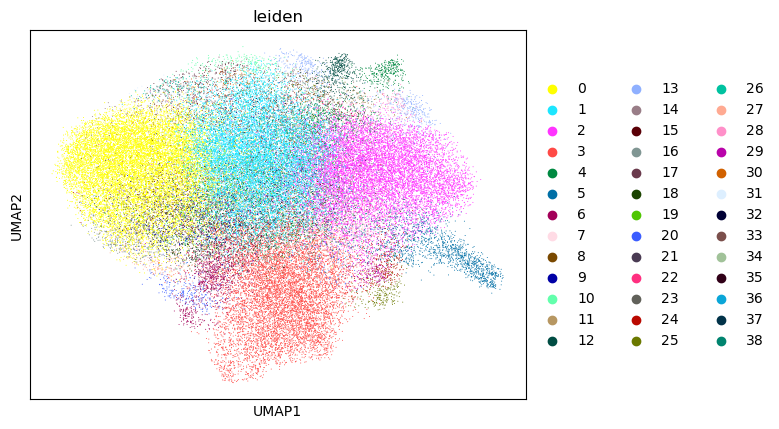

In [25]:
sc.pl.umap(d2_lapa, color="leiden", palette=sc.pl.palettes.default_102,)

/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


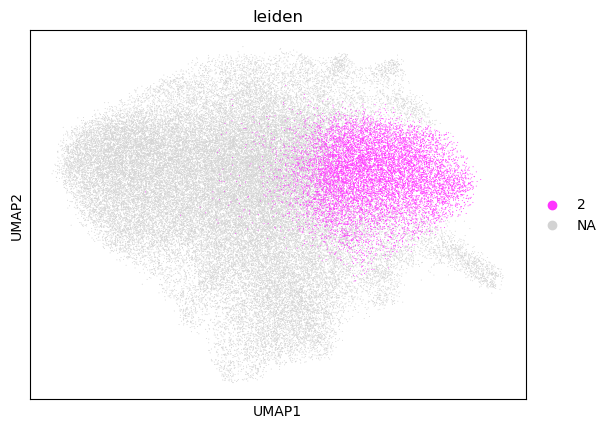

In [26]:
sc.pl.umap(d2_lapa, color="leiden", palette=sc.pl.palettes.default_102, groups=["2"])

In [27]:
d2_lapa_map = {
    "1": "ISCs",
    "0": "PCs",
    "4": "Proliferating progenitor cells",
    "2": "Secretory progenitor cells",
    "3": "Enterocytes",
    "20": "Goblet cells",
}


In [28]:
d2_lapa.obs["manual_label"] = "Unlabeled"

In [29]:
for cl, lab in d2_lapa_map.items():
    sel = d2_lapa.obs["leiden"] == cl
    d2_lapa.obs.loc[sel, "manual_label"] = lab

In [30]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d2_lapa = d2_lapa[
    ~d2_lapa.obs['participant'].isin(removed_participant_labels),
].copy()

In [31]:
cell_type = "Secretory progenitor cells"
sub = d2_lapa[d2_lapa.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [32]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(8320, 28941)
8320 28941


In [33]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6,...,AC011043.1,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCAAAGCCACTAA-1,0,0,0,0,1.0,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
AAACCAAAGGGCTCTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCAAACTCAA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCAATTCATC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCATGAGTTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGGTTGTCATTAGC-1,0,0,0,0,0,0,0,0,1.0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGGTTGTTGCATGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTACGTTGGTCTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.0,0
TGTGTTAGTATGGTCT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


In [35]:
pb_counts = pb_counts.T
pb_counts

pb_id,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
AL627309.1,3.0,6.0,8.0
AL627309.5,15.0,19.0,25.0
AL627309.4,0,0,0
AP006222.2,0,0,0
LINC01409,113.0,160.0,147.0
...,...,...,...
AC240274.1,73.0,51.0,63.0
AC004556.3,0,1.0,96.0
AC136352.3,1.0,1.0,1.0
AC007325.4,24.0,40.0,25.0


### Merge the pseudobulk dfs

In [36]:
original_pb = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_secretory_pcs.csv", index_col=0)

In [37]:
original_pb

,H329_G2D2,H896_G2D2,H897_G2D2
MIR1302-2HG,0.0,0.0,0.0
AL627309.1,6.0,1.0,0.0
AL627309.3,0.0,0.0,0.0
AL627309.5,5.0,3.0,0.0
LINC01409,44.0,34.0,10.0
...,...,...,...
AC004556.3,1.0,29.0,0.0
AC136352.3,1.0,1.0,0.0
AC136616.1,0.0,0.0,0.0
AC007325.4,6.0,9.0,5.0


In [38]:
pb_counts

pb_id,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
AL627309.1,3.0,6.0,8.0
AL627309.5,15.0,19.0,25.0
AL627309.4,0,0,0
AP006222.2,0,0,0
LINC01409,113.0,160.0,147.0
...,...,...,...
AC240274.1,73.0,51.0,63.0
AC004556.3,0,1.0,96.0
AC136352.3,1.0,1.0,1.0
AC007325.4,24.0,40.0,25.0


In [39]:
df_combined = pd.concat([original_pb, pb_counts], axis=1)


In [40]:
df_combined

,H329_G2D2,H896_G2D2,H897_G2D2,H329_G2D2_Lapa,H439_G2D2_Lapa,H896_G2D2_Lapa
MIR1302-2HG,0.0,0.0,0.0,NaN,NaN,NaN
AL627309.1,6.0,1.0,0.0,3.0,6.0,8.0
AL627309.3,0.0,0.0,0.0,NaN,NaN,NaN
AL627309.5,5.0,3.0,0.0,15.0,19.0,25.0
LINC01409,44.0,34.0,10.0,113.0,160.0,147.0
...,...,...,...,...,...,...
FATE1,NaN,NaN,NaN,0,0,0
ATP2B3,NaN,NaN,NaN,0,0,0
HCFC1-AS1,NaN,NaN,NaN,0,0,0
OPN1MW,NaN,NaN,NaN,0,0,0


In [41]:
df_combined.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/df_combined_secretory_pcs.csv")

In [42]:
df_combined = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/df_combined_secretory_pcs.csv", index_col=0)

### Transpose the matrix, and create a metadata df, for pydeseq2

In [43]:
df_clean = df_combined.fillna(0)
df_clean = df_clean.astype(int)


In [44]:
counts_df = df_clean.T   # now: rows = samples, cols = genes
counts_df.shape


(6, 29512)

In [45]:
samples = counts_df.index

condition = ["Lapa" if "Lapa" in s else "Dz" for s in samples]
participant = [s.split("_")[0] for s in samples]

clinical_df = pd.DataFrame(
    {
        "condition": condition,
        "participant": participant,
    },
    index=samples,   # IMPORTANT: index must match counts_df.index
)

clinical_df


,condition,participant
H329_G2D2,Dz,H329
H896_G2D2,Dz,H896
H897_G2D2,Dz,H897
H329_G2D2_Lapa,Lapa,H329
H439_G2D2_Lapa,Lapa,H439
H896_G2D2_Lapa,Lapa,H896


### Run pydeseq2

In [46]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DESeq dataset
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors="condition",  # use the 'condition' column
)

# fit dispersions + LFCs
dds.deseq2()

# compare Lapa vs Dz
stats = DeseqStats(
    dds,
    contrast=["condition", "Lapa", "Dz"],  # tested_level, reference_level
)

stats.summary()
res = stats.results_df
res.head()


Using None as control genes, passed at DeseqDataSet initialization


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_2132/2528878090.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

python(2295) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2296) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2297) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2298) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2299) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2300) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2301) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(2302) 

Log2 fold change & Wald test p-value: condition Lapa vs Dz
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
MIR1302-2HG   0.000000             NaN       NaN       NaN       NaN       NaN
AL627309.1    2.755916       -0.237487  1.113636 -0.213253  0.831129       NaN
AL627309.3    0.000000             NaN       NaN       NaN       NaN       NaN
AL627309.5    6.693687        1.216867  0.756059  1.609488  0.107510       NaN
LINC01409    60.056726        0.542421  0.290348  1.868177  0.061737  0.225266
...                ...             ...       ...       ...       ...       ...
FATE1         0.000000             NaN       NaN       NaN       NaN       NaN
ATP2B3        0.000000             NaN       NaN       NaN       NaN       NaN
HCFC1-AS1     0.000000             NaN       NaN       NaN       NaN       NaN
OPN1MW        0.000000             NaN       NaN       NaN       NaN       NaN
TEX28         0.074089       -0.962181  4.443132 -0.216555  0.828555    

... done in 0.50 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MIR1302-2HG,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.1,2.755916,-0.237487,1.113636,-0.213253,0.831129,NaN
AL627309.3,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.5,6.693687,1.216867,0.756059,1.609488,0.107510,NaN
LINC01409,60.056726,0.542421,0.290348,1.868177,0.061737,0.225266


### Volcano plot

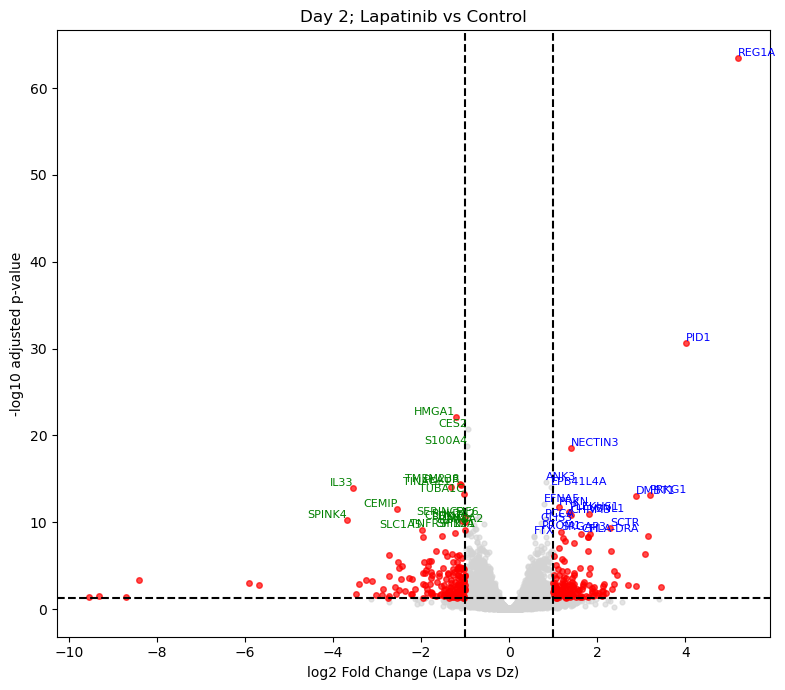

In [47]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# ----- define significance (optional) -----
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

# ---- select top 20 up-regulated genes ----
top_up = (
    df[df["log2FoldChange"] > 0]
    .sort_values("padj")
    .head(20)
)

# ---- select top 20 down-regulated genes ----
top_down = (
    df[df["log2FoldChange"] < 0]
    .sort_values("padj")
    .head(20)
)

plt.figure(figsize=(8,7))

# ---- plot non-significant ----
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.6,
    s=12,
)

# ---- plot significant ----
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.7,
    s=16,
)

# ---- threshold lines ----
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

# ---- label top up-regulated ----
for gene, row in top_up.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="blue",
        ha="left",
        va="bottom"
    )

# ---- label top down-regulated ----
for gene, row in top_down.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="green",
        ha="right",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Day 2; Lapatinib vs Control")
plt.tight_layout()
plt.show()


### Save the deseq output

In [48]:
res.to_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d2_secretory_pcs_deseq2_results.csv",
    index=True
)